# Analiza podataka i priprema za modeliranje
### Procjena potrebnog vremena učenja studentskih obveza

Ova bilježnica (eng. *notebook*) provodi cjelovitu pripremu podataka prikupljenih anketom:
učitavanje, čišćenje, eksplorativnu analizu s vizualizacijama te pripremu značajki za
modeliranje. Cilj je na temelju svojstava koje korisnik poznaje u trenutku unosa obveze
(ECTS, težina kolegija, udio bodova, vrsta obveze, težina obveze i samopouzdanje)
pripremiti podatke za model koji procjenjuje potreban broj sati učenja.

**Napomena o varijabli „dani učenja".** Iako je anketa prikupila i podatak o broju dana
učenja, on se u ovoj analizi u potpunosti izostavlja. Razlog je taj što korisnik u trenutku
unosa nove obveze taj podatak ne poznaje — riječ je o ishodu koji aplikacija tek treba
procijeniti. Uključivanje takve varijable dovelo bi do curenja informacija (eng. *data
leakage*) i modela koji je točan na papiru, ali neprimjenjiv u praksi.

## 1. Priprema okruženja i učitavanje podataka

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Estetika grafova
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 11
sns.set_palette("muted")

Ako radite u Google Colabu, prenesite datoteku `anketa_long.csv` (izbornik lijevo →
*Files* → *Upload*) ili je učitajte izravno kroz sljedeću ćeliju.

In [80]:
# U Colabu se datoteka može prenijeti ovom naredbom (odkomentirajte po potrebi):
# from google.colab import files
# uploaded = files.upload()

df = pd.read_csv("anketa_long.csv")
print("Dimenzije skupa:", df.shape)
df.head()

Dimenzije skupa: (305, 19)


,id_ispitanika,fakultet,razina_studija,godina_studija,podrucje_studija,prosjecna_uspjesnost,kolegij,ects_kolegija,tezina_kolegija,bodovi_kolegija,tip_obveze,tip_izvorni,max_bodova,tezina_obveze,sigurnost_prije,dani_ucenja,sati_ucenja,ostvareni_bodovi,polozeno_prvi_put
0,5,Prirodoslovno-matematički fakultet (Zagreb),Diplomski studij,2. godina,Tehničke znanosti,Vrlo dobra,Markovljevi lanci,5.0,8.0,100,Mini test,Mini test,10.0,3.0,1.0,5.0,25.0,1,Nije primjenjivo
1,5,Prirodoslovno-matematički fakultet (Zagreb),Diplomski studij,2. godina,Tehničke znanosti,Vrlo dobra,Markovljevi lanci,5.0,8.0,100,Ispit,Ispit,90.0,9.0,4.0,21.0,100.0,49,Ne
2,5,Prirodoslovno-matematički fakultet (Zagreb),Diplomski studij,2. godina,Tehničke znanosti,Vrlo dobra,Teorija vjerojatnosti,5.0,7.0,100,Kolokvij,Kolokvij,50.0,6.0,1.0,14.0,70.0,25,Nije primjenjivo
3,5,Prirodoslovno-matematički fakultet (Zagreb),Diplomski studij,2. godina,Tehničke znanosti,Vrlo dobra,Teorija vjerojatnosti,5.0,7.0,100,Kolokvij,Kolokvij,50.0,7.0,3.0,5.0,37.0,27,Da
4,5,Prirodoslovno-matematički fakultet (Zagreb),Diplomski studij,2. godina,Tehničke znanosti,Vrlo dobra,Bayesovska statistika,5.0,4.0,100.0,Ispit,Ispit,100.0,5.0,3.0,7.0,21.0,50,Da


Pregled osnovnih informacija o stupcima i tipovima podataka:

In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 305 entries, 0 to 304
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id_ispitanika         305 non-null    int64  
 1   fakultet              299 non-null    object 
 2   razina_studija        305 non-null    object 
 3   godina_studija        305 non-null    object 
 4   podrucje_studija      305 non-null    object 
 5   prosjecna_uspjesnost  305 non-null    object 
 6   kolegij               305 non-null    object 
 7   ects_kolegija         305 non-null    float64
 8   tezina_kolegija       305 non-null    float64
 9   bodovi_kolegija       305 non-null    object 
 10  tip_obveze            305 non-null    object 
 11  tip_izvorni           305 non-null    object 
 12  max_bodova            274 non-null    float64
 13  tezina_obveze         305 non-null    float64
 14  sigurnost_prije       305 non-null    float64
 15  dani_ucenja           3

## 2. Čišćenje podataka

U ovom se koraku podaci dovode u oblik pogodan za analizu i modeliranje.

### 2.1. Pretvaranje decimalnih zareza u točke

Dio numeričkih vrijednosti unesen je s decimalnim zarezom (npr. `49,5`), zbog čega ih
`pandas` tumači kao tekst. Sljedeća ćelija te stupce pretvara u brojeve.

In [82]:
num_cols = ["ects_kolegija","tezina_kolegija","bodovi_kolegija","max_bodova",
            "tezina_obveze","sigurnost_prije","sati_ucenja","ostvareni_bodovi"]

for c in num_cols:
    df[c] = pd.to_numeric(df[c].astype(str).str.replace(",", "."), errors="coerce")

df[num_cols].describe().round(1)

,ects_kolegija,tezina_kolegija,bodovi_kolegija,max_bodova,tezina_obveze,sigurnost_prije,sati_ucenja,ostvareni_bodovi
count,305.0,305.0,305.0,274.0,305.0,305.0,305.0,247.0
mean,5.8,6.4,85.3,47.6,6.1,5.0,46.1,39.5
std,2.5,2.4,27.6,37.1,2.6,2.4,81.8,30.1
min,1.0,1.0,6.0,0.0,1.0,1.0,0.0,0.0
25%,5.0,5.0,73.0,20.0,4.0,3.0,10.0,16.0
50%,5.0,7.0,100.0,40.0,7.0,5.0,22.0,35.0
75%,6.0,8.0,100.0,80.0,8.0,7.0,50.0,60.0
max,24.0,10.0,200.0,200.0,10.0,10.0,900.0,188.0


### 2.2. Uklanjanje varijable „dani učenja"

Kako je objašnjeno na početku, varijabla o danima učenja izostavlja se iz analize.

In [83]:
for col in ["dani_ucenja", "godina_num"]:
    if col in df.columns:
        df = df.drop(columns=col)
print("Preostali stupci:")
print(list(df.columns))

Preostali stupci:
['id_ispitanika', 'fakultet', 'razina_studija', 'godina_studija', 'podrucje_studija', 'prosjecna_uspjesnost', 'kolegij', 'ects_kolegija', 'tezina_kolegija', 'bodovi_kolegija', 'tip_obveze', 'tip_izvorni', 'max_bodova', 'tezina_obveze', 'sigurnost_prije', 'sati_ucenja', 'ostvareni_bodovi', 'polozeno_prvi_put']


### 2.3. Standardizacija vrste obveze

Zadržavaju se uobičajene vrste obveza, a rijetki i netipični unosi (npr. slobodni tekstualni
odgovori) grupiraju se u kategoriju *Ostalo*.

In [84]:
STANDARD = {"Kolokvij","Ispit","Usmeni ispit","Seminar",
            "Projekt","Mini test","Zadaće","Labos"}

df["tip_obveze"] = df["tip_obveze"].apply(lambda t: t if t in STANDARD else "Ostalo")
df["tip_obveze"].value_counts()

tip_obveze
Kolokvij        87
Ispit           73
Usmeni ispit    49
Seminar         33
Projekt         22
Mini test       18
Zadaće          10
Labos            7
Ostalo           6
Name: count, dtype: int64

### 2.4. Uklanjanje nemogućih vrijednosti ciljne varijable

Obveze za koje je zabilježeno 0 sati učenja uklanjaju se jer takva vrijednost nije smislena
(svaka obveza zahtijeva određeno vrijeme). Ekstremno velike vrijednosti zadržavaju se jer
mogu predstavljati stvarno zahtjevne obveze; njihov će se utjecaj ublažiti logaritamskom
transformacijom u fazi modeliranja.

In [85]:
prije = len(df)
df = df[(df["sati_ucenja"].notna()) & (df["sati_ucenja"] > 0)].copy()
print(f"Uklonjeno {prije - len(df)} obaveza s 0 ili nedostajućim satima.")
print(f"Broj obaveza nakon čišćenja: {len(df)}")

Uklonjeno 4 obaveza s 0 ili nedostajućim satima.
Broj obaveza nakon čišćenja: 301


### 2.5. Izvedena značajka: udio bodova obveze u kolegiju

Udio bodova (postotak ocjene) izračunava se kao omjer bodova pojedine obveze i ukupnih
bodova kolegija. Time se dobiva usporediva mjera važnosti obveze neovisna o bodovnoj skali
pojedinog kolegija.

In [86]:
df["postotak_ocjene"] = (df["max_bodova"] / df["bodovi_kolegija"] * 100).round(1)
df[["max_bodova","bodovi_kolegija","postotak_ocjene"]].describe().round(1)

,max_bodova,bodovi_kolegija,postotak_ocjene
count,272.0,301.0,272.0
mean,47.9,85.3,63.1
std,37.1,27.7,56.7
min,0.0,6.0,0.0
25%,20.0,73.0,23.6
50%,40.0,100.0,50.0
75%,80.0,100.0,100.0
max,200.0,200.0,375.0


### 2.6. Pregled nedostajućih vrijednosti

Prikaz broja nedostajućih vrijednosti po stupcu. Značajka `max_bodova` (i iz nje izvedeni
`postotak_ocjene`) mjestimično nedostaje; ti se podaci zadržavaju jer odabrani model
(stablo odluke i njegove ansambl inačice) može raditi s nedostajućim vrijednostima.

In [87]:
nedostaje = df.isna().sum()
nedostaje = nedostaje[nedostaje > 0].sort_values(ascending=False)
print("Nedostajuće vrijednosti po stupcu:")
print(nedostaje if len(nedostaje) else "Nema nedostajućih vrijednosti.")

Nedostajuće vrijednosti po stupcu:
ostvareni_bodovi     56
postotak_ocjene      29
max_bodova           29
polozeno_prvi_put    25
fakultet              6
dtype: int64


## 3. Eksplorativna analiza podataka (EDA)

U ovom se dijelu podaci vizualiziraju kako bi se razumjela njihova raspodjela i odnosi među varijablama.

### 3.1. Raspodjela ciljne varijable (sati učenja)

Sljedeći grafovi prikazuju raspodjelu sati učenja na izvornoj i logaritamskoj skali.
Izvorna je raspodjela izrazito zakošena udesno (nekoliko obaveza traži vrlo velik broj sati),
dok se logaritamskom transformacijom raspodjela približava simetričnoj, što opravdava
treniranje modela na log-transformiranoj ciljnoj varijabli.

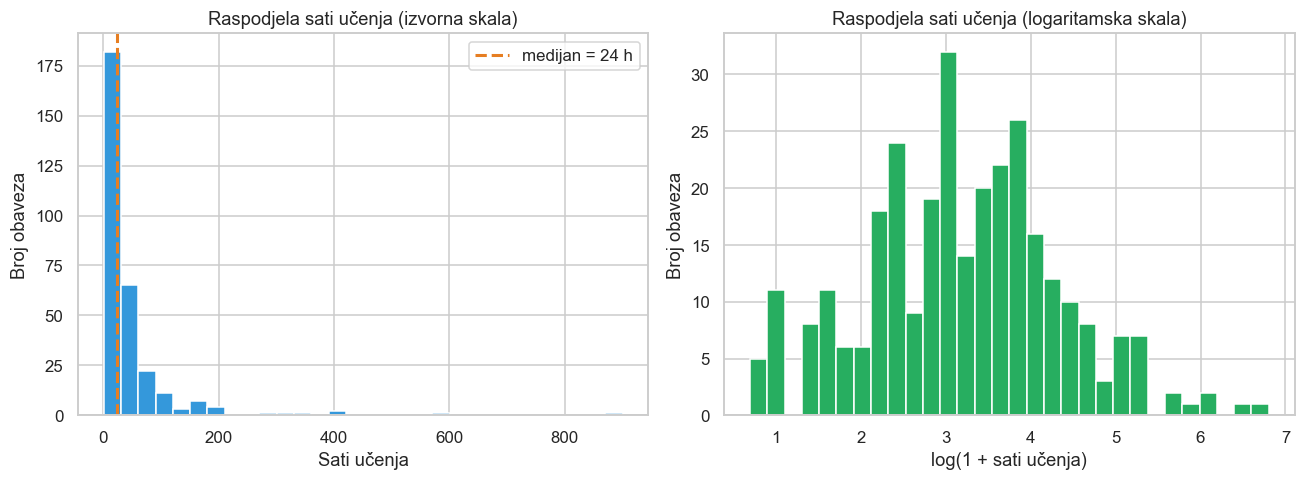

In [88]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(df["sati_ucenja"], bins=30, color="#3498db", edgecolor="white")
axes[0].axvline(df["sati_ucenja"].median(), color="#e67e22", ls="--", lw=2,
                label=f"medijan = {df['sati_ucenja'].median():.0f} h")
axes[0].set(title="Raspodjela sati učenja (izvorna skala)",
            xlabel="Sati učenja", ylabel="Broj obaveza")
axes[0].legend()

axes[1].hist(np.log1p(df["sati_ucenja"]), bins=30, color="#27ae60", edgecolor="white")
axes[1].set(title="Raspodjela sati učenja (logaritamska skala)",
            xlabel="log(1 + sati učenja)", ylabel="Broj obaveza")

plt.tight_layout(); plt.show()

**Tumačenje.** Raspodjela sati učenja izrazito je zakošena udesno: većina obaveza zahtijeva razmjerno malo sati (medijan iznosi 30 sati), no postoji dugačak rep prema vrlo visokim vrijednostima (do 900 sati). Zbog toga je prosjek (oko 51 sat) znatno viši od medijana. Na logaritamskoj skali raspodjela postaje gotovo simetrična, čime se opravdava kasnija logaritamska transformacija ciljne varijable pri modeliranju.

### 3.2. Raspodjele numeričkih značajki

Histogrami svih numeričkih značajki pružaju uvid u njihove raspodjele i eventualne
neuobičajene vrijednosti. Ovi grafovi opisuju samo raspodjelu pojedine značajke; njihov
odnos s ciljnom varijablom prikazan je u odjeljku 3.6.

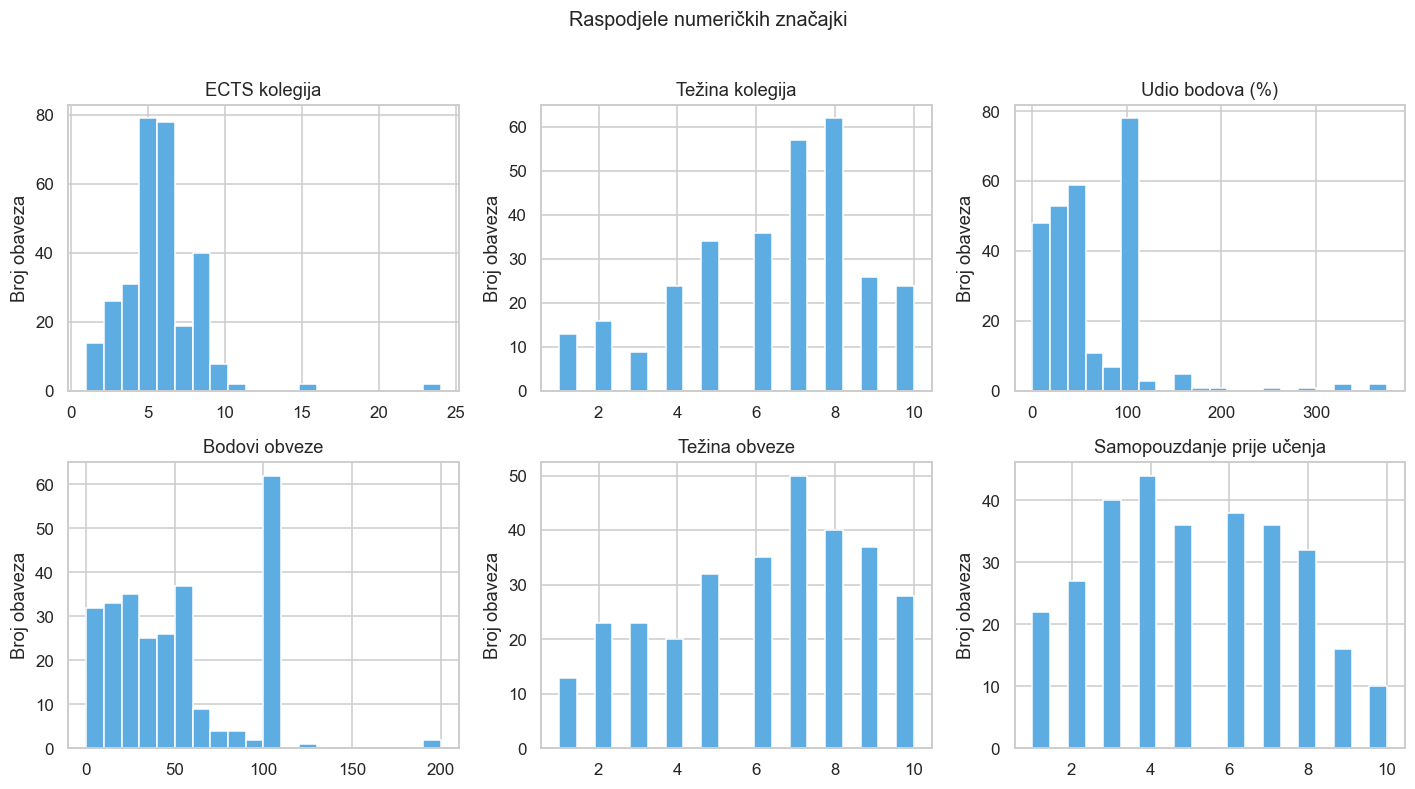

In [89]:
feat_num = ["ects_kolegija","tezina_kolegija","postotak_ocjene",
            "max_bodova","tezina_obveze","sigurnost_prije"]
naslovi = ["ECTS kolegija","Težina kolegija","Udio bodova (%)",
           "Bodovi obveze","Težina obveze","Samopouzdanje prije učenja"]

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, col, t in zip(axes.ravel(), feat_num, naslovi):
    ax.hist(df[col].dropna(), bins=20, color="#5dade2", edgecolor="white")
    ax.set(title=t, ylabel="Broj obaveza")
plt.suptitle("Raspodjele numeričkih značajki", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

**Tumačenje.** Histogrami pokazuju kako su pojedine značajke raspodijeljene u uzorku. ECTS bodovi najčešće se kreću oko 5–6, a težine kolegija i obveza pomaknute su prema višim vrijednostima, što upućuje na to da su ispitanici uglavnom unosili zahtjevnije kolegije. Udio bodova i bodovi obveze imaju vrhove oko okruglih vrijednosti (primjerice 50 i 100), što odražava način bodovanja obveza. Ovi grafovi opisuju samo raspodjelu svake značajke, dok se njihova povezanost sa satima učenja razmatra u odjeljku 3.6.

### 3.3. Sati učenja po vrsti obveze

Prikaz koliko se sati učenja tipično troši na pojedinu vrstu obveze. Zbog izrazite
zakošenosti podataka i pojedinačnih ekstremnih vrijednosti prikaz je na logaritamskoj skali,
čime se jasnije vide razlike među vrstama obveza. Vrste su poredane prema medijanu, a
pojedinačne obveze prikazane su točkama.

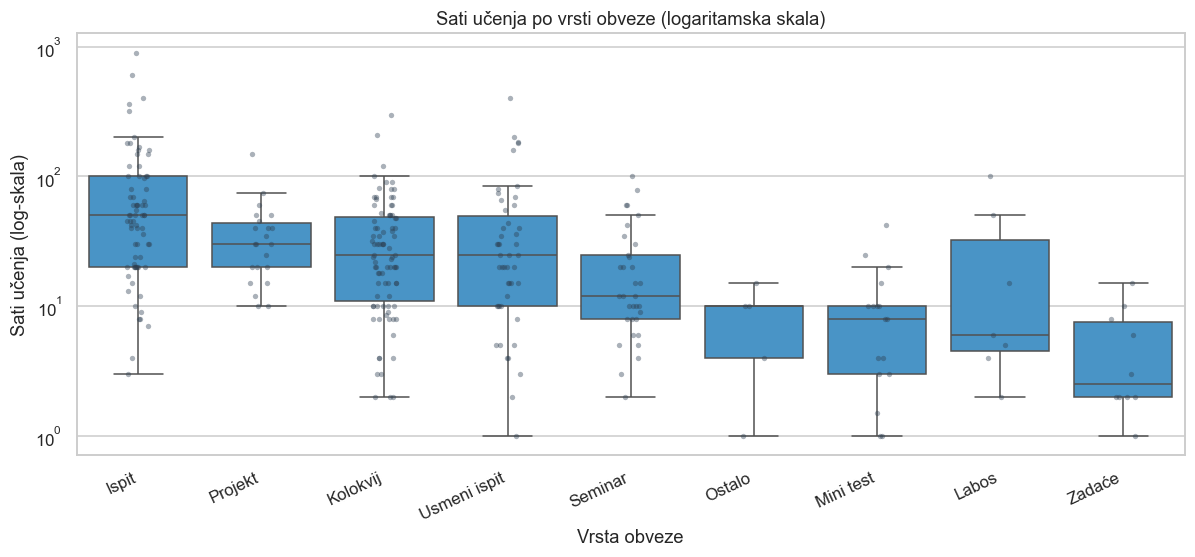

In [90]:
poredak = (df.groupby("tip_obveze")["sati_ucenja"].median()
           .sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(11, 5.2))
sns.boxplot(data=df, x="tip_obveze", y="sati_ucenja", order=poredak,
            ax=ax, color="#3498db", showfliers=False)
sns.stripplot(data=df, x="tip_obveze", y="sati_ucenja", order=poredak,
              ax=ax, size=3.5, color="#2c3e50", alpha=0.4)
ax.set_yscale("log")
ax.set(title="Sati učenja po vrsti obveze (logaritamska skala)",
       xlabel="Vrsta obveze", ylabel="Sati učenja (log-skala)")
plt.xticks(rotation=25, ha="right")
plt.tight_layout(); plt.show()

**Tumačenje.** Vrste obveza jasno se razlikuju po potrebnom vremenu. Najviše sati zahtijevaju ispiti (medijan 50 sati), slijede kolokviji i projekti (oko 30 sati), dok obveze poput zadaća, laboratorijskih vježbi i mini testova zahtijevaju najmanje vremena (medijani ispod 20 sati). Ovakva razlika potvrđuje da je vrsta obveze smislena značajka za procjenu vremena učenja. Logaritamska skala korištena je kako pojedinačne ekstremne vrijednosti ne bi prikrile razlike među skupinama.

### 3.4. Broj obaveza po vrsti i području studija

Pregled zastupljenosti pojedinih vrsta obveza te područja studija u prikupljenom uzorku.

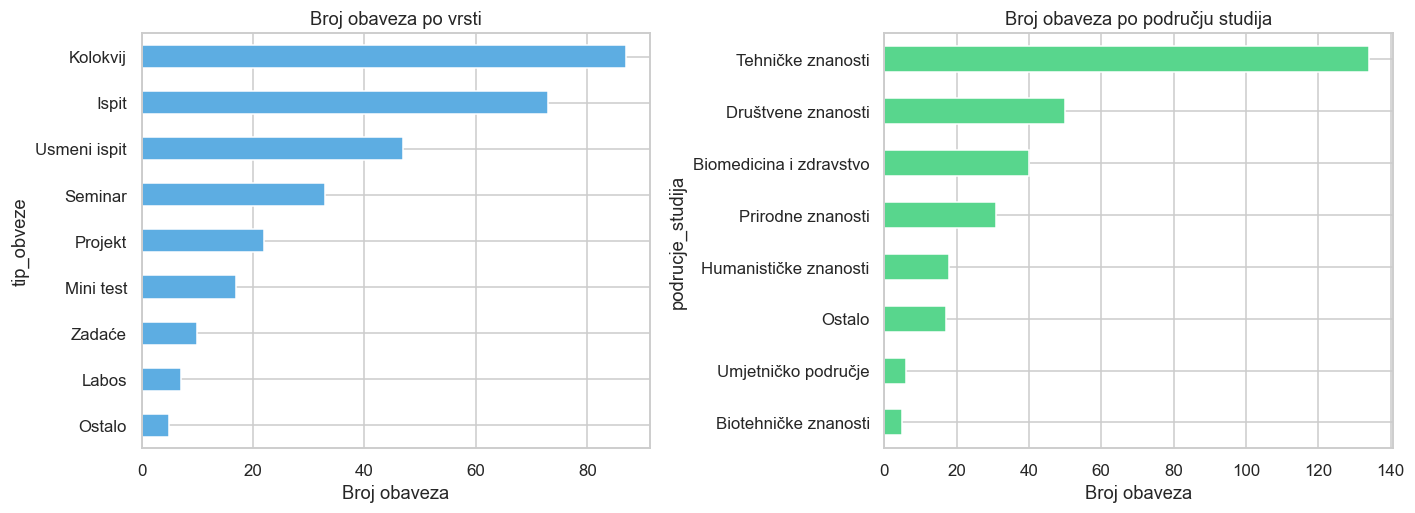

In [91]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

df["tip_obveze"].value_counts().plot(kind="barh", ax=axes[0], color="#5dade2")
axes[0].set(title="Broj obaveza po vrsti", xlabel="Broj obaveza")
axes[0].invert_yaxis()

df["podrucje_studija"].value_counts().plot(kind="barh", ax=axes[1], color="#58d68d")
axes[1].set(title="Broj obaveza po području studija", xlabel="Broj obaveza")
axes[1].invert_yaxis()

plt.tight_layout(); plt.show()

**Tumačenje.** Grafovi prikazuju sastav prikupljenog uzorka. Među vrstama obveza najzastupljeniji su kolokviji i ispiti, dok su laboratorijske vježbe, mini testovi i zadaće rjeđi. Po području studija prevladavaju tehničke znanosti, što je važno ograničenje uzorka: model je pretežno naučen na podacima iz tehničkih područja, pa njegove procjene mogu biti manje pouzdane za druga područja.

### 3.5. Korelacijska matrica (heatmap)

Toplinska karta prikazuje Pearsonove koeficijente korelacije među numeričkim značajkama i
ciljnom varijablom. Vrijednosti bliske +1 označavaju jaku pozitivnu, a bliske −1 jaku
negativnu povezanost. Za tumačenje je najvažniji zadnji redak/stupac (SATI), koji pokazuje
koliko je svaka značajka povezana s ciljnom varijablom.

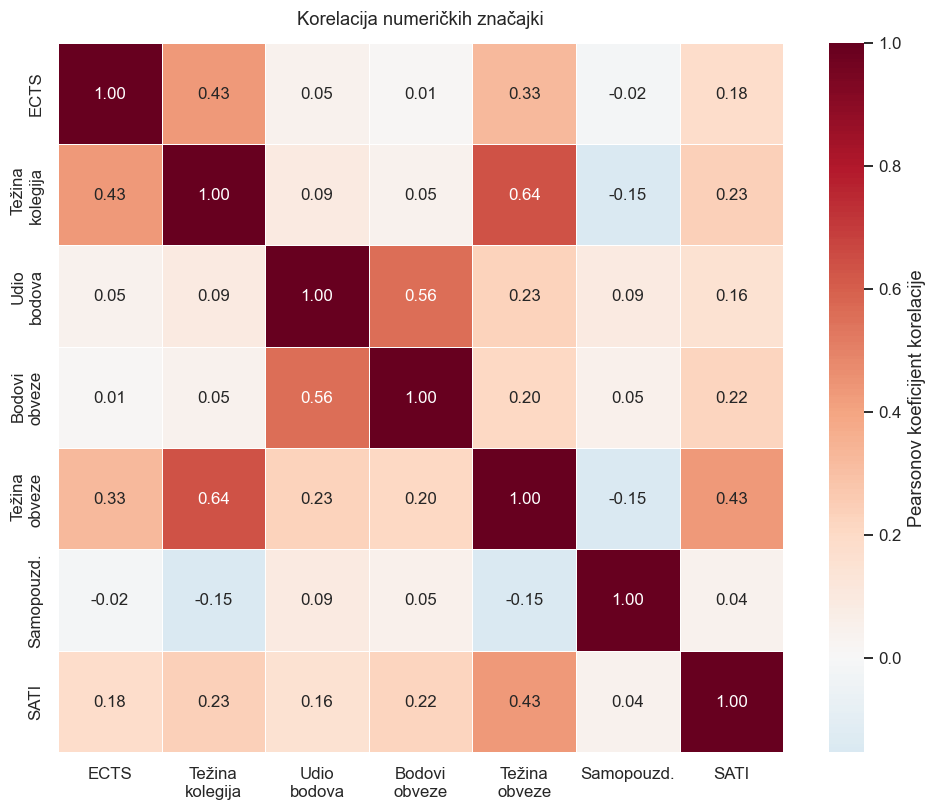

In [92]:
kor_cols = ["ects_kolegija","tezina_kolegija","postotak_ocjene","max_bodova",
            "tezina_obveze","sigurnost_prije","sati_ucenja"]
oznake = ["ECTS","Težina\nkolegija","Udio\nbodova","Bodovi\nobveze",
          "Težina\nobveze","Samopouzd.","SATI"]

corr = df[kor_cols].corr()
fig, ax = plt.subplots(figsize=(9, 7.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            xticklabels=oznake, yticklabels=oznake, linewidths=0.5,
            cbar_kws={"label":"Pearsonov koeficijent korelacije"}, ax=ax)
ax.set_title("Korelacija numeričkih značajki", pad=12)
plt.tight_layout(); plt.show()

**Tumačenje.** Za procjenu sati učenja najvažniji je zadnji redak (SATI). Od svih značajki najjaču povezanost sa satima učenja pokazuje težina obveze (r = 0.42), dok su ostale značajke slabije povezane, a samopouzdanje gotovo da nije povezano (r = 0.04). Uočljiva je i međusobna povezanost težine kolegija i težine obveze (r = 0.60) te udjela bodova i bodova obveze (r = 0.50), što je očekivano jer te značajke opisuju srodna svojstva.

Radi lakšeg tumačenja, korelacije svake značajke sa satima učenja prikazane su i
zasebnim stupčastim grafom, poredane po jakosti.

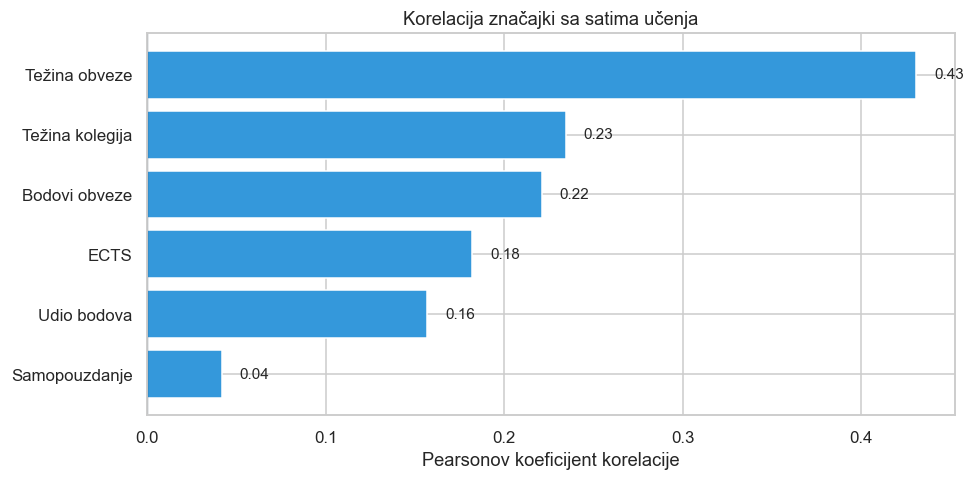

In [93]:
kor_feat = ["ects_kolegija","tezina_kolegija","postotak_ocjene",
            "max_bodova","tezina_obveze","sigurnost_prije"]
oznake_map = {"ects_kolegija":"ECTS", "tezina_kolegija":"Težina kolegija",
              "postotak_ocjene":"Udio bodova", "max_bodova":"Bodovi obveze",
              "tezina_obveze":"Težina obveze", "sigurnost_prije":"Samopouzdanje"}

kor = (df[kor_feat + ["sati_ucenja"]].corr()["sati_ucenja"]
       .drop("sati_ucenja").sort_values())

fig, ax = plt.subplots(figsize=(9, 4.5))
boje = ["#e74c3c" if v < 0 else "#3498db" for v in kor.values]
ax.barh([oznake_map[i] for i in kor.index], kor.values, color=boje)
ax.axvline(0, color="#2c3e50", lw=0.8)
for i, v in enumerate(kor.values):
    ax.text(v + (0.01 if v >= 0 else -0.01), i, f"{v:.2f}",
            va="center", ha="left" if v >= 0 else "right", fontsize=10)
ax.set(title="Korelacija značajki sa satima učenja",
       xlabel="Pearsonov koeficijent korelacije")
plt.tight_layout(); plt.show()

**Tumačenje.** Stupčasti prikaz izdvaja samo povezanost svake značajke sa satima učenja, poredanu po jakosti. Time se jasno vidi da je težina obveze najkorisniji pojedinačni pokazatelj, a da samopouzdanje gotovo ne doprinosi procjeni. Relativno slabe korelacije upućuju na to da nijedna pojedinačna značajka ne određuje vrijeme učenja samostalno, nego da je za procjenu potrebna njihova kombinacija.

### 3.6. Odnos značajki i sati učenja

Za razliku od histograma iz odjeljka 3.2, koji prikazuju samo raspodjelu pojedine značajke,
ovdje se prikazuje odnos svake značajke s ciljnom varijablom (satima učenja). Za značajke
ocijenjene na skali od 1 do 10 (težina obveze, samopouzdanje) koristi se boxplot, koji
pokazuje kako se raspodjela sati mijenja po pojedinoj razini. Za kontinuirane značajke
(ECTS, udio bodova) koristi se raspršeni dijagram s pravcem trenda. Radi bolje čitljivosti
prikaz je ograničen na do 300 sati.

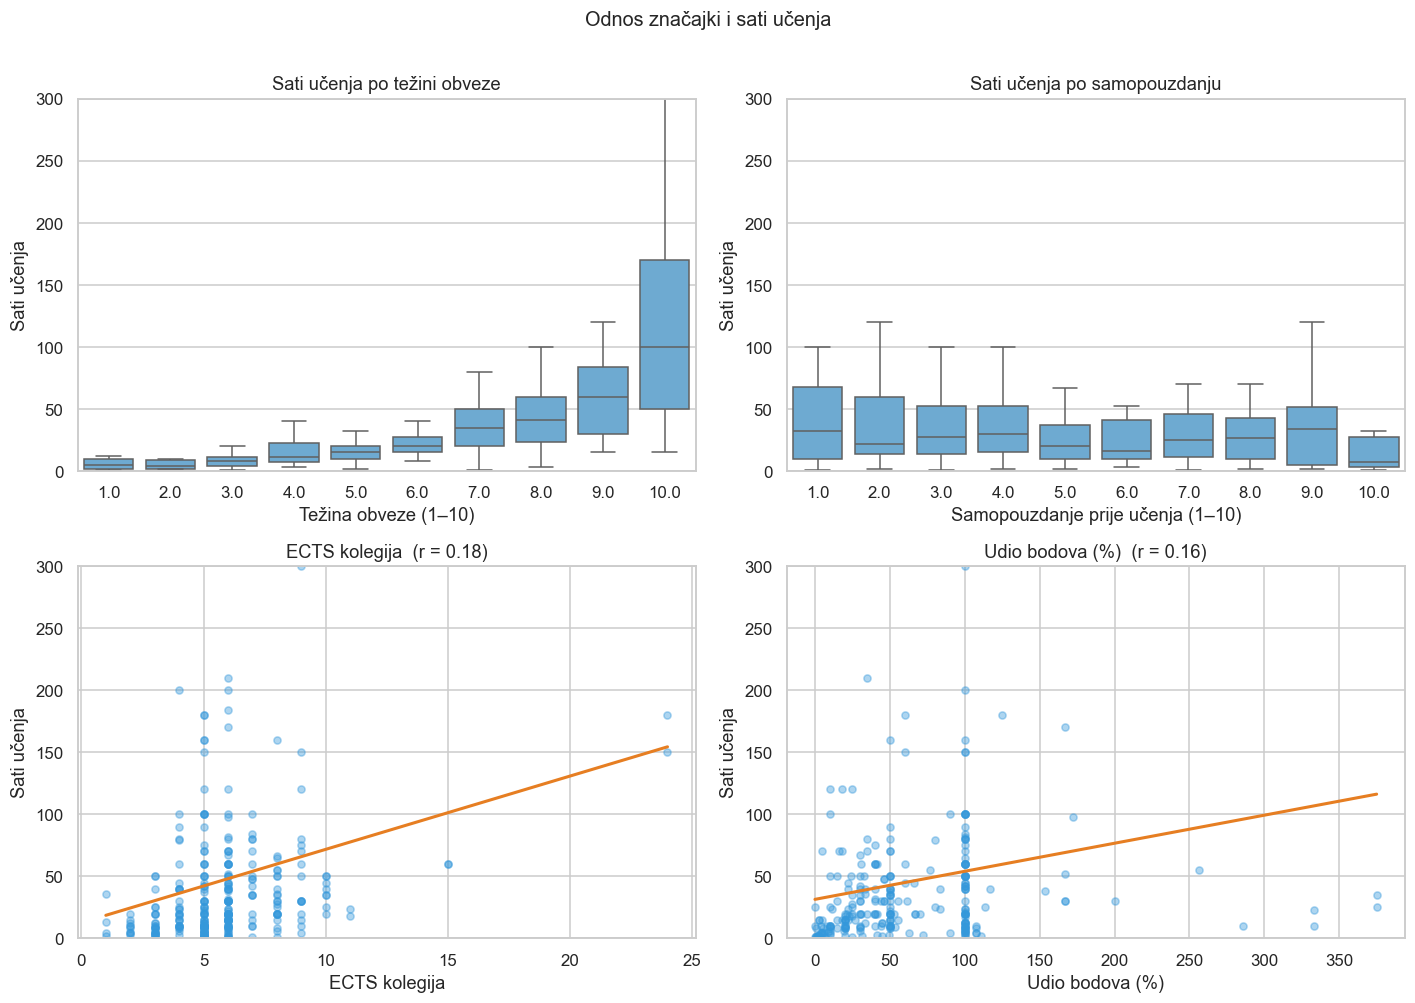

In [94]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Ocjene 1-10 -> boxplot
sns.boxplot(data=df, x="tezina_obveze", y="sati_ucenja",
            ax=axes[0,0], color="#5dade2", showfliers=False)
axes[0,0].set(title="Sati učenja po težini obveze",
              xlabel="Težina obveze (1–10)", ylabel="Sati učenja", ylim=(0,300))

sns.boxplot(data=df, x="sigurnost_prije", y="sati_ucenja",
            ax=axes[0,1], color="#5dade2", showfliers=False)
axes[0,1].set(title="Sati učenja po samopouzdanju",
              xlabel="Samopouzdanje prije učenja (1–10)", ylabel="Sati učenja", ylim=(0,300))

# Kontinuirane -> scatter s trendom
for ax, col, lab in [(axes[1,0], "ects_kolegija", "ECTS kolegija"),
                     (axes[1,1], "postotak_ocjene", "Udio bodova (%)")]:
    sub = df[[col, "sati_ucenja"]].dropna()
    ax.scatter(sub[col], sub["sati_ucenja"], alpha=0.4, color="#3498db", s=22)
    z = np.polyfit(sub[col], sub["sati_ucenja"], 1)
    xs = np.linspace(sub[col].min(), sub[col].max(), 50)
    ax.plot(xs, np.polyval(z, xs), color="#e67e22", lw=2)
    r = sub[col].corr(sub["sati_ucenja"])
    ax.set(title=f"{lab}  (r = {r:.2f})", xlabel=lab, ylabel="Sati učenja", ylim=(0,300))

plt.suptitle("Odnos značajki i sati učenja", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

**Tumačenje.** Za težinu obveze uočava se blagi porast medijana sati učenja s povećanjem težine, što potvrđuje njezinu prediktivnu vrijednost. Kod samopouzdanja nema jasnog trenda, što je u skladu s njegovom niskom korelacijom. Za ECTS bodove i udio bodova pravac trenda blago raste, ali uz velik rasap točaka, što znači da te značajke same po sebi slabo objašnjavaju vrijeme učenja.

### 3.7. Prosječni sati učenja po vrsti obveze i razini studija

Grupni prikaz prosjeka omogućuje usporedbu opterećenja kroz razine studija.

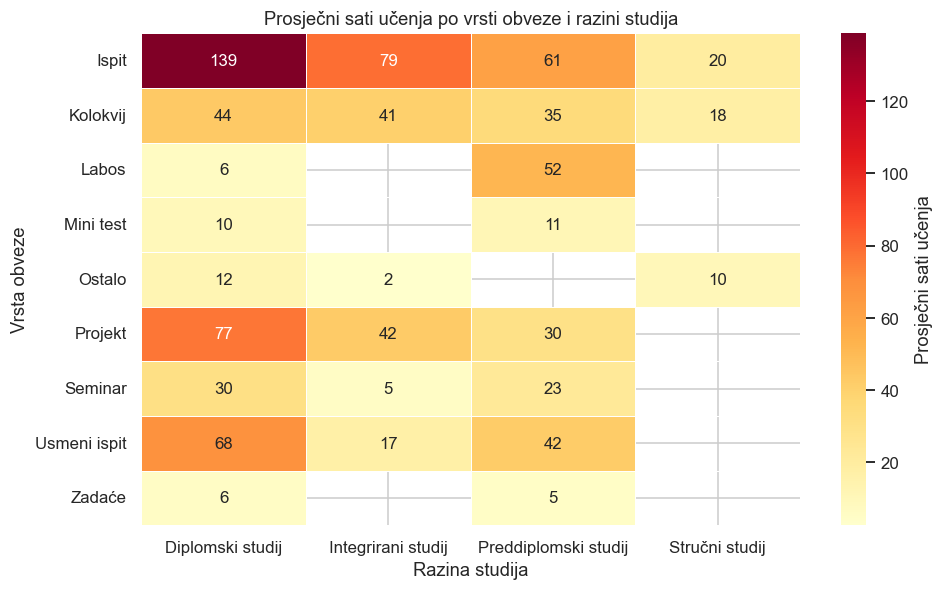

In [95]:
pivot = (df.pivot_table(values="sati_ucenja", index="tip_obveze",
                        columns="razina_studija", aggfunc="mean"))
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlOrRd",
            linewidths=0.5, cbar_kws={"label":"Prosječni sati učenja"}, ax=ax)
ax.set(title="Prosječni sati učenja po vrsti obveze i razini studija",
       xlabel="Razina studija", ylabel="Vrsta obveze")
plt.tight_layout(); plt.show()

**Tumačenje.** Toplinska karta prikazuje prosječno vrijeme učenja za kombinacije vrste obveze i razine studija. Vrijednosti potvrđuju ranije uočene obrasce — ispiti dosljedno zahtijevaju najviše vremena — no za pojedine kombinacije broj je zapisa malen, pa te prosjeke treba tumačiti oprezno.

### 3.8. Detaljniji pregled lakših obveza

U ovom se dijelu podrobnije razmatraju obveze manjeg opsega (mini testovi, zadaće, laboratorijske vježbe i seminari), budući da su se pokazale osjetljivima pri procjeni. Sljedeća tablica prikazuje broj primjera te prosječne i granične vrijednosti sati učenja po svakoj vrsti obveze.

In [96]:
# Prosječni sati učenja po vrsti obveze
pregled = (df.groupby("tip_obveze")["sati_ucenja"]
           .agg(broj="count", medijan="median", prosjek="mean",
                najmanje="min", najvise="max")
           .round(1)
           .sort_values("medijan"))
print(pregled.to_string())

              broj  medijan  prosjek  najmanje  najvise
tip_obveze                                             
Zadaće          10      2.5      5.1       1.0     15.0
Labos            7      6.0     26.0       2.0    100.0
Mini test       17      8.0     10.3       1.0     42.0
Ostalo           5     10.0      8.0       1.0     15.0
Seminar         33     12.0     22.3       2.0    100.0
Usmeni ispit    47     25.0     47.9       1.0    400.0
Kolokvij        87     25.0     37.2       2.0    300.0
Projekt         22     30.0     37.4      10.0    150.0
Ispit           73     50.0     90.1       3.0    900.0


**Sati učenja po vrsti lakše obveze.** Prikaz raspona i pojedinačnih vrijednosti sati učenja za mini testove, zadaće, laboratorijske vježbe i seminare. Boxplot pokazuje tipične vrijednosti i odstupanja, a pojedinačne točke otkrivaju koliko su odgovori raspršeni unutar svake vrste.

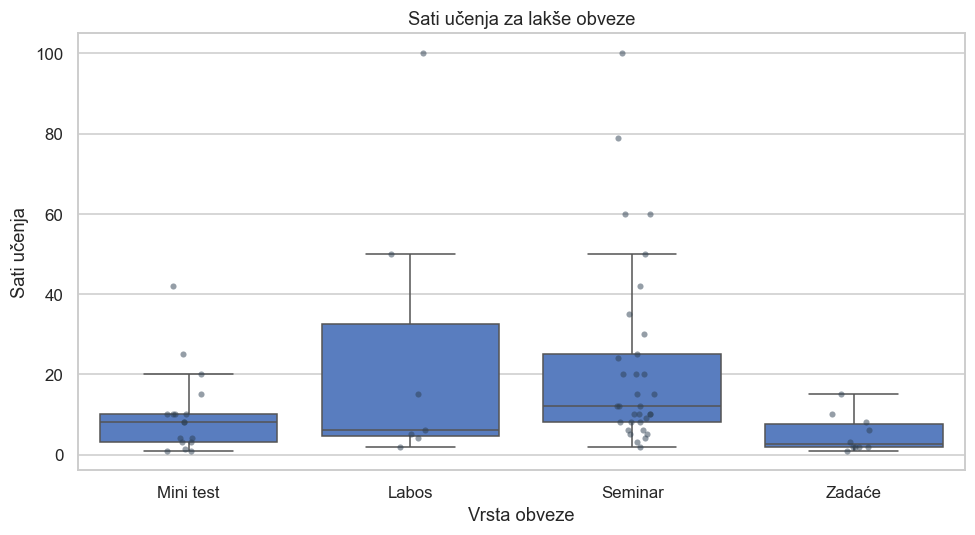

Medijan sati po tipu:
tip_obveze
Labos         6.0
Mini test     8.0
Seminar      12.0
Zadaće        2.5


In [97]:
import matplotlib.pyplot as plt
import seaborn as sns

laki = df[df["tip_obveze"].isin(["Mini test", "Zadaće", "Labos", "Seminar"])]

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=laki, x="tip_obveze", y="sati_ucenja", ax=ax, showfliers=False)
sns.stripplot(data=laki, x="tip_obveze", y="sati_ucenja", ax=ax,
              color="#2c3e50", size=4, alpha=0.5)
ax.set(title="Sati učenja za lakše obveze", xlabel="Vrsta obveze", ylabel="Sati učenja")
plt.tight_layout(); plt.show()

# Ispiši i medijane da imaš brojku
print("Medijan sati po tipu:")
print(laki.groupby("tip_obveze")["sati_ucenja"].median().to_string())

**Odnos težine obveze i sati učenja.** Ovaj prikaz pokazuje kako se broj sati mijenja s težinom obveze kod lakših vrsta. Time se ilustrira zašto model najviše oslonac nalazi u težini obveze — vrijeme učenja jasno raste s njom, više nego s brojem bodova.

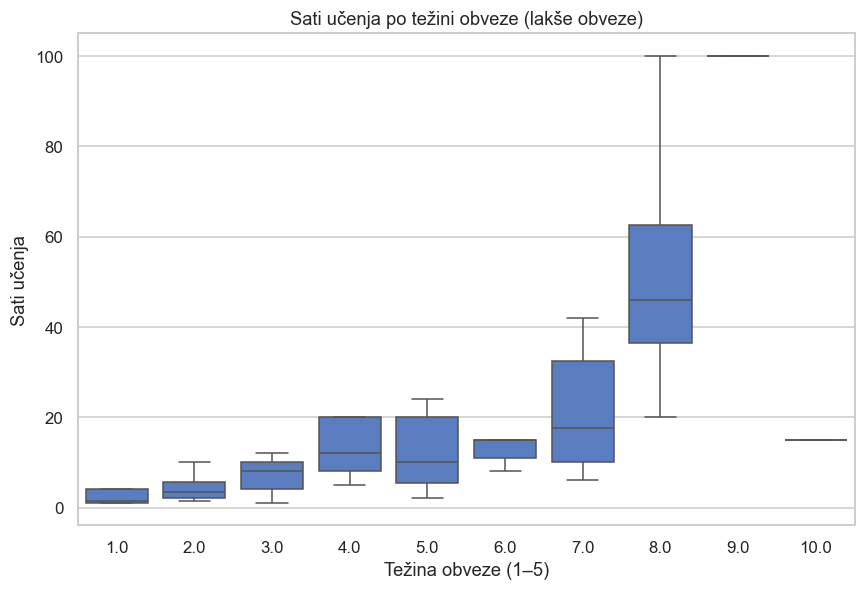

Prosječni sati po težini obveze:
               count  median
tezina_obveze               
1.0                4     1.5
2.0               14     3.5
3.0               13     8.0
4.0                9    12.0
5.0                8    10.0
6.0                7    15.0
7.0                6    17.5
8.0                4    46.0
9.0                1   100.0
10.0               1    15.0


In [98]:
fig, ax = plt.subplots(figsize=(8, 5.5))
sns.boxplot(data=laki, x="tezina_obveze", y="sati_ucenja", ax=ax, showfliers=False)
ax.set(title="Sati učenja po težini obveze (lakše obveze)",
       xlabel="Težina obveze (1–5)", ylabel="Sati učenja")
plt.tight_layout(); plt.show()

# Prosjek sati po težini
print("Prosječni sati po težini obveze:")
print(laki.groupby("tezina_obveze")["sati_ucenja"].agg(["count", "median"]).round(1).to_string())

**Usporedba ranijih i novijih ispitanika.** Nakon što je uočeno da model precjenjuje lakše obveze, provedeno je dodatno prikupljanje podataka usmjereno upravo na njih. Ova ćelija uspoređuje medijan sati učenja za lakše obveze između ranije prikupljenih odgovora i onih dodanih naknadno, čime se provjerava jesu li novi ispitanici doista unosili obveze manjeg opsega.

In [99]:
# Noviji ispitanici (ID >= 52 su zadnje dodani)
laki_kopija = laki.copy()
laki_kopija["skup"] = laki_kopija["id_ispitanika"].apply(
    lambda x: "noviji (52+)" if x >= 52 else "raniji")

print("Medijan sati po tipu — raniji vs noviji ispitanici:")
usporedba = (laki_kopija.groupby(["tip_obveze", "skup"])["sati_ucenja"]
             .median().unstack())
print(usporedba.round(1).to_string())

Medijan sati po tipu — raniji vs noviji ispitanici:
skup        noviji (52+)  raniji
tip_obveze                      
Labos               27.5     6.0
Mini test            4.0    17.5
Seminar             12.5    12.0
Zadaće               2.0     6.0


## 4. Priprema značajki za modeliranje

U ovom se koraku definiraju ulazne značajke i ciljna varijabla te se kategorijske značajke pretvaraju u numerički oblik.

### 4.1. Odabir značajki

Kao ulazne značajke koriste se isključivo svojstva koja su korisniku poznata u trenutku
unosa obveze:

- **ECTS kolegija** — opseg kolegija,
- **težina kolegija** — subjektivna procjena zahtjevnosti kolegija,
- **udio bodova (postotak ocjene)** — važnost obveze unutar kolegija,
- **vrsta obveze** — kolokvij, ispit, projekt i slično,
- **težina obveze** — subjektivna procjena zahtjevnosti obveze,
- **samopouzdanje prije učenja** — procjena predznanja.

Ciljna varijabla jest **broj sati učenja**.

In [100]:
znacajke = ["ects_kolegija","tezina_kolegija","postotak_ocjene",
            "tip_obveze","tezina_obveze","sigurnost_prije"]
cilj = "sati_ucenja"

X = df[znacajke].copy()
y = df[cilj].copy()

print("Oblik matrice značajki X:", X.shape)
print("Oblik ciljne varijable y:", y.shape)
X.head()

Oblik matrice značajki X: (301, 6)
Oblik ciljne varijable y: (301,)


,ects_kolegija,tezina_kolegija,postotak_ocjene,tip_obveze,tezina_obveze,sigurnost_prije
0,5.0,8.0,10.0,Mini test,3.0,1.0
1,5.0,8.0,90.0,Ispit,9.0,4.0
2,5.0,7.0,50.0,Kolokvij,6.0,1.0
3,5.0,7.0,50.0,Kolokvij,7.0,3.0
4,5.0,4.0,100.0,Ispit,5.0,3.0


### 4.2. Provjera multikolinearnosti (VIF)

Multikolinearnost je pojava kad su ulazne značajke međusobno jako povezane, zbog čega postaju suvišne i mogu narušiti stabilnost modela. Kao mjera koristi se faktor inflacije varijance (VIF): vrijednost bliska 1 označava nepovezanost, dok se vrijednosti veće od 5 smatraju pokazateljem problematične multikolinearnosti.

In [101]:
from sklearn.linear_model import LinearRegression

# VIF za svaku značajku: VIF = 1 / (1 - R²), gdje je R² iz regresije te značajke na ostale
vif_znacajke = ["ects_kolegija","tezina_kolegija","postotak_ocjene","tezina_obveze","sigurnost_prije"]
d_vif = df[vif_znacajke].dropna()

vif = {}
for col in vif_znacajke:
    ostale = [c for c in vif_znacajke if c != col]
    r2 = LinearRegression().fit(d_vif[ostale], d_vif[col]).score(d_vif[ostale], d_vif[col])
    vif[col] = round(1/(1-r2), 2) if r2 < 1 else float("inf")

pd.Series(vif, name="VIF").sort_values(ascending=False)

tezina_kolegija    2.09
tezina_obveze      1.97
ects_kolegija      1.26
postotak_ocjene    1.08
sigurnost_prije    1.06
Name: VIF, dtype: float64

**Tumačenje.** Svi VIF-ovi znatno su manji od 5 (najviši je oko 1,7), što znači da među odabranim značajkama nema problematične multikolinearnosti. Značajke nose međusobno neovisne informacije i sve se zadržavaju u modelu.

### 4.3. Kodiranje kategorijske značajke

Vrsta obveze pretvara se u numerički oblik postupkom *one-hot* kodiranja, pri čemu svaka
vrsta obveze postaje zasebni binarni stupac.

In [102]:
X_enc = pd.get_dummies(X, columns=["tip_obveze"], prefix="tip")
print("Značajke nakon kodiranja:")
print(list(X_enc.columns))
X_enc.head()

Značajke nakon kodiranja:
['ects_kolegija', 'tezina_kolegija', 'postotak_ocjene', 'tezina_obveze', 'sigurnost_prije', 'tip_Ispit', 'tip_Kolokvij', 'tip_Labos', 'tip_Mini test', 'tip_Ostalo', 'tip_Projekt', 'tip_Seminar', 'tip_Usmeni ispit', 'tip_Zadaće']


,ects_kolegija,tezina_kolegija,postotak_ocjene,tezina_obveze,sigurnost_prije,tip_Ispit,tip_Kolokvij,tip_Labos,tip_Mini test,tip_Ostalo,tip_Projekt,tip_Seminar,tip_Usmeni ispit,tip_Zadaće
0,5.0,8.0,10.0,3.0,1.0,False,False,False,True,False,False,False,False,False
1,5.0,8.0,90.0,9.0,4.0,True,False,False,False,False,False,False,False,False
2,5.0,7.0,50.0,6.0,1.0,False,True,False,False,False,False,False,False,False
3,5.0,7.0,50.0,7.0,3.0,False,True,False,False,False,False,False,False,False
4,5.0,4.0,100.0,5.0,3.0,True,False,False,False,False,False,False,False,False


### 4.4. Logaritamska transformacija ciljne varijable

Zbog izrazite zakošenosti, ciljna se varijabla logaritamski transformira. Model se trenira
na `log(1 + sati)`, a predviđene se vrijednosti pri interpretaciji vraćaju na izvornu skalu.

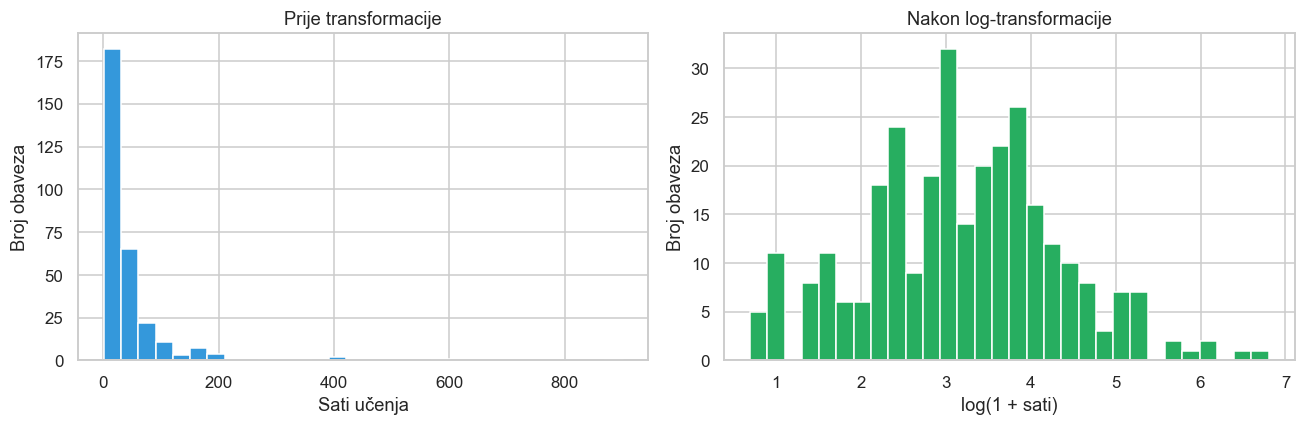

In [103]:
y_log = np.log1p(y)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(y, bins=30, color="#3498db", edgecolor="white")
axes[0].set(title="Prije transformacije", xlabel="Sati učenja", ylabel="Broj obaveza")
axes[1].hist(y_log, bins=30, color="#27ae60", edgecolor="white")
axes[1].set(title="Nakon log-transformacije", xlabel="log(1 + sati)", ylabel="Broj obaveza")
plt.tight_layout(); plt.show()

**Tumačenje.** Usporedba potvrđuje učinak logaritamske transformacije: izvorna, izrazito zakošena raspodjela sati učenja nakon transformacije postaje gotovo simetrična. Takva je raspodjela pogodnija za modele koji bolje rade uz ujednačeniju ciljnu varijablu, čime se smanjuje nesrazmjeran utjecaj pojedinačnih ekstremnih vrijednosti.

### 4.5. Spremanje pripremljenih podataka

Pripremljene matrice značajki i ciljne varijable spremaju se za korištenje u fazi
modeliranja. Uz značajke i ciljnu varijablu, sprema se i identifikator ispitanika
(`id_ispitanika`), koji će u fazi modeliranja poslužiti za grupno dijeljenje podataka kako
obveze istog ispitanika ne bi istovremeno završile u skupu za treniranje i vrednovanje.

In [104]:
priprema = X_enc.copy()
priprema["sati_ucenja"] = y.values
priprema["sati_ucenja_log"] = y_log.values
priprema["id_ispitanika"] = df["id_ispitanika"].values   # za grupno dijeljenje pri modeliranju
priprema.to_csv("podaci_za_model.csv", index=False, encoding="utf-8-sig")
print("Spremljeno: podaci_za_model.csv", priprema.shape)
priprema.head()

Spremljeno: podaci_za_model.csv (301, 17)


,ects_kolegija,tezina_kolegija,postotak_ocjene,tezina_obveze,sigurnost_prije,tip_Ispit,tip_Kolokvij,tip_Labos,tip_Mini test,tip_Ostalo,tip_Projekt,tip_Seminar,tip_Usmeni ispit,tip_Zadaće,sati_ucenja,sati_ucenja_log,id_ispitanika
0,5.0,8.0,10.0,3.0,1.0,False,False,False,True,False,False,False,False,False,25.0,3.258097,5
1,5.0,8.0,90.0,9.0,4.0,True,False,False,False,False,False,False,False,False,100.0,4.615121,5
2,5.0,7.0,50.0,6.0,1.0,False,True,False,False,False,False,False,False,False,70.0,4.262680,5
3,5.0,7.0,50.0,7.0,3.0,False,True,False,False,False,False,False,False,False,37.0,3.637586,5
4,5.0,4.0,100.0,5.0,3.0,True,False,False,False,False,False,False,False,False,21.0,3.091042,5


---
## Sažetak

U ovoj su bilježnici podaci prikupljeni anketom očišćeni, analizirani i pripremljeni za
modeliranje. Provedeno je uklanjanje neispravnih vrijednosti, standardizacija vrsta obveza
te izračun izvedene značajke o udjelu bodova. Eksplorativna analiza pokazala je izrazitu
zakošenost ciljne varijable te umjerenu povezanost s težinom obveze, dok su ostale značajke
slabije povezane sa satima učenja. Pripremljeni skup podataka (`podaci_za_model.csv`)
predstavlja ulaz za sljedeću fazu — izradu i vrednovanje modela strojnog učenja za procjenu
potrebnog vremena učenja.